In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
import math
import pandas as pd

# Linear regression of the probe cell constant

In [2]:
# get the data for probe 1
data = pd.read_csv(".\Data\Probe_calibration.csv")
current = data["I"]
voltage = data["V"]
cond = data["Cond"]

# get the data for probe 2
data_probe2 = pd.read_csv(".\Data\Probe_2_calibration.csv")
current_probe2 = data_probe2["I"]
voltage_probe2 = data_probe2["V"]
cond_probe2 = data_probe2["Cond"]

# get the number of data points
n_data = len(cond)

In [3]:
# calculate the uncertainty in the current readings
mean_current = (current + current_probe2) / 2

# percent error of each probe relative to the average
curr_percent_err_probe1 = np.abs((current - mean_current) / mean_current) * 100
curr_percent_err_probe2 = np.abs((current_probe2 - mean_current) / mean_current) * 100

# Mean absolute percent error
curr_mape_probe1 = np.mean(curr_percent_err_probe1)
curr_mape_probe2 = np.mean(curr_percent_err_probe2)

print("Mean absolute percent error of Probe 1 current:", curr_mape_probe1)
print("Mean absolute percent error of Probe 2 current:", curr_mape_probe2)

Mean absolute percent error of Probe 1 current: 0.32953105196450955
Mean absolute percent error of Probe 2 current: 0.32953105196451515


In [4]:
# calculate the uncertainty in the voltage measurements
mean_voltage = (voltage + voltage_probe2) / 2

# percent error of each probe relative to the average
volt_percent_err_probe1 = np.abs((voltage - mean_voltage) / mean_voltage) * 100
volt_percent_err_probe2 = np.abs((voltage_probe2 - mean_voltage) / mean_voltage) * 100

# Mean absolute percent error
volt_mape_probe1 = np.mean(volt_percent_err_probe1)
volt_mape_probe2 = np.mean(volt_percent_err_probe2)

print("Mean absolute percent error of Probe 1 voltage:", volt_mape_probe1)
print("Mean absolute percent error of Probe 2 voltage:", volt_mape_probe2)

Mean absolute percent error of Probe 1 voltage: 0.22661112623108373
Mean absolute percent error of Probe 2 voltage: 0.22661112623108848


In [5]:
# compute the input variables
current_divide_voltage = [current[i]/voltage[i] for i in range(n_data)]
current_divide_voltage2 = [current_probe2[i]/voltage_probe2[i] for i in range(n_data)]

# Matrix of input variables
X = np.zeros((n_data, 1))
X[:, 0] = current_divide_voltage

X2 = np.zeros((n_data, 1))
X2[:, 0] = current_divide_voltage2

In [6]:
# X transpose multiply X
X_transpose_times_X = np.matmul(np.transpose(X), X)
X2_transpose_times_X2 = np.matmul(np.transpose(X2), X2)

# Get the inverse of X.T @ X
X_transpose_times_X_inv = np.linalg.inv(X_transpose_times_X)
X2_transpose_times_X2_inv = np.linalg.inv(X2_transpose_times_X2)

In [7]:
# X transpose multiply conductivity
X_transpose_times_cond = np.matmul(np.transpose(X), cond)
X2_transpose_times_cond_probe2 = np.matmul(np.transpose(X2), cond_probe2)

# calculate the parameter estimate in micro/cm
beta_hat = np.matmul(X_transpose_times_X_inv, X_transpose_times_cond)
beta_hat2 = np.matmul(X2_transpose_times_X2_inv, X2_transpose_times_cond_probe2)

In [8]:
# convert the cell constant from micro per cm to per cm
cell_constant = beta_hat * 10**(-6)
cell_constant_probe_2 = beta_hat2 * 10**(-6)
print(f"The cell constant of Probe 1 is: {cell_constant}")
print(f"The cell constant of Probe 2 is: {cell_constant_probe_2}")

The cell constant of Probe 1 is: [0.49674524]
The cell constant of Probe 2 is: [0.48575172]


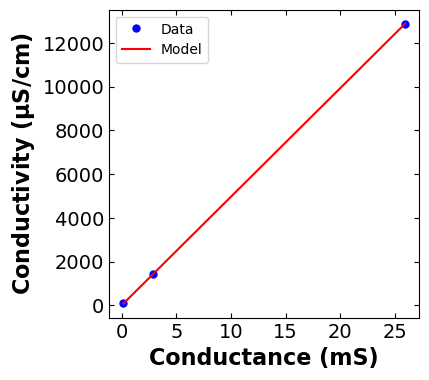

In [9]:
# get the model predictions
cond_pred = np.matmul(beta_hat, np.transpose(X))

# conver the conductance from S to mS
current_divide_voltage_plot = [current_divide_voltage[i] * 1000 for i in range(n_data)]

# plot comparing the predictions with the data
fig = plt.figure(figsize=(4,4))
plt.plot(current_divide_voltage_plot, cond, "b.", markersize=10, label="Data")
plt.plot(current_divide_voltage_plot, cond_pred, "r-", label="Model")
plt.xlabel("Conductance (mS)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.show()

Percent prediction residuals are: [np.float64(-5.15422908305469), np.float64(0.9244792410344264), np.float64(-0.011022423428056986)]


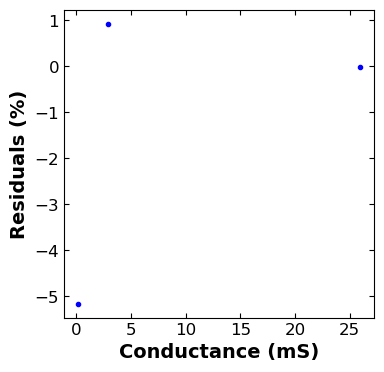

In [10]:
# calculate the prediction residuals
e = [cond_pred[i] - cond[i] for i in range(n_data)]

# percent prediction residuals
percent_residuals = [(e[i]/cond[i])*100 for i in range(n_data)]
print(f"Percent prediction residuals are: {percent_residuals}")

# plot the percent prediction residuals
fig = plt.figure(figsize=(4,4))
plt.plot(current_divide_voltage_plot, percent_residuals, "b.")
plt.xlabel("Conductance (mS)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)
plt.show()

In [11]:
# calculate the sum of squared errors
sse = sum(e[i]**2 for i in range(n_data))

# calculate the variance of the measurement error
variance_meas_error = sse/(n_data - 1)
meas_error_standard_dev = math.sqrt(variance_meas_error)
print(f"Variance of the measurement error is: {variance_meas_error}")
print(f"Standard deviation of the measurement error is: {meas_error_standard_dev}")

Variance of the measurement error is: 95.69983879203038
Standard deviation of the measurement error is: 9.782629441618974


## Calculate the R-squared value

In [12]:
# mean value of the conductivity measurements
cond_data_mean = np.mean(cond)

# deviation of the conductivity measurements from the mean value
cond_data_dev = [cond[i] - cond_data_mean for i in range(n_data)]

# sum of squared errors for the deviation between the conductivity measurements and the mean value
sse_cond_data_dev = sum(cond_data_dev[i]**2 for i in range(n_data))

# r-squared
r_squared = 1 - (sse/sse_cond_data_dev)
print(f"r-squared of the fit is: {r_squared}")

r-squared of the fit is: 0.9999980666435334


## Compute the uncertainty in the estimated parameters

In [13]:
# define the uncertainty in the conductivity measurements
cond_uncertainty = 0.93 # %

def compute_propagated_variance(Chi, I, V):
    """
    Propagates the uncertainty from the input and output variables 
    to the estimated parameter

    Arguments:
        Chi: float or int, conductivity of the solution in micro.S/cm
        I: float or int, applied electrical current
           from the conductivity sensor in milli.A
        V: float or int, potential difference measured by the 
           conductivity sensor in milli.V

    Returns:
        sigma_beta_per_cm: float or int, uncertainty in the estimated 
                           parameter in (cm)^-1
    """
    # calculate the partial derivatives
    dphi_dChi = V / I
    
    dphi_dV = Chi / I
    
    dphi_dI = - Chi * V / (I**2)

    # compute the standard deviation of the input and output variables
    sigma_Chi = (cond_uncertainty/100) * Chi
    sigma_I = (curr_mape_probe1/100) * I
    sigma_V = (volt_mape_probe1/100) * V
    
    # compute the variance propagation
    sigma_beta_squared = (
        (dphi_dChi * sigma_Chi)**2
        + (dphi_dV * sigma_V)**2
        + (dphi_dI * sigma_I)**2
    )
    
    # calculate the standard deviation of the estimated parameter
    sigma_beta = np.sqrt(sigma_beta_squared)

    # convert the standard deviation from micro/cm to (cm)^-1
    sigma_beta_per_cm = sigma_beta * 10**(-6)

    return sigma_beta_per_cm

# define the standard deviation of the estimated parameters
beta_hat_standard_dev = []
beta_hat_standard_dev_probe2 = []
for i in range(n_data):
    beta_hat_standard_dev.append(
        compute_propagated_variance(cond[i], current[i], voltage[i])
    )

    beta_hat_standard_dev_probe2.append(
        compute_propagated_variance(cond_probe2[i], current_probe2[i], voltage_probe2[i])
    )

beta_hat_uncertainty = np.mean(beta_hat_standard_dev)
beta_hat_uncertainty_probe2 = np.mean(beta_hat_standard_dev_probe2)

print("The uncertainty in Probe 1 cell constant is:", beta_hat_uncertainty)
print("The uncertainty in Probe 2 cell constant is:", beta_hat_uncertainty_probe2)

The uncertainty in Probe 1 cell constant is: 0.005104701330801749
The uncertainty in Probe 2 cell constant is: 0.005061754811051518
